<a href="https://colab.research.google.com/github/innoted-latam/tp1_dne_uba/blob/main/TP1_PEREZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
ME72: Maestría en Métodos Cuantitativos para la Gestión y Análisis de Datos
M72109: Analisis de datos no estructurados
Universidad de Buenos Aires - Facultad de Ciencias Economicas (UBA-FCE)
Año: 2026
Estudiante: PÉREZ, LUCAS ENZO
```

## Preparación del ambiente

### NLP

In [1]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/m72109/nlp/normalization.py \
    --quiet --no-clobber --directory-prefix ./m72109/nlp/
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/m72109/nlp/transformation.py \
    --quiet --no-clobber --directory-prefix ./m72109/nlp/
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/docs/nlp/neural/sequences-word2vec.txt \
    --quiet --no-clobber

In [2]:
!pip install -r sequences-word2vec.txt --quiet
!pip install datasets --quiet
!pip install transformers --quiet
!pip install unidecode --quiet
!python -m spacy download es_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 33.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Sets de datos

Descargamos el set de datos:

In [3]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/ground_truth.csv --directory-prefix ./Data/ --quiet --no-clobber
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/Features/caption_features.csv --directory-prefix ./Data/Features/ --quiet --no-clobber

Cargamos el set de datos:

In [4]:
import pandas as pd

labels = pd.read_csv('Data/ground_truth.csv')
cc = pd.read_csv('Data/Features/caption_features.csv', names=['sequence_name','cc'], header=0)

Los conjuntos de datos utilizados en este desafío son los siguientes:

*   `ground_truth.csv`: Contiene la verdad fundamental para el problema de clasificación. Este archivo incluye información sobre segmentos de video (`movie_name`, `start(sec)`, `end(sec)`) y su correspondiente puntuación de memorabilidad (`memorability_score`). **Aunque contiene varias columnas, para el problema de clasificación que abordaremos, la columna clave es `memorable`, que indica la probabilidad de que una persona recuerde el video.**
*   `caption_features.csv`: Contiene las características de las "captions" (descripciones textuales) asociadas a cada segmento de video. Cada segmento de video se identifica por `sequence_name` y cuenta con una descripción en la columna `cc`.

**Para proceder con el análisis, será necesario combinar estas etiquetas (`ground_truth.csv`) con las características (`caption_features.csv`).**

## Solución

In [5]:
# =============================================================================
# BLOQUE 1: CARGA, FUSIÓN DE DATOS Y DIAGNÓSTICO INICIAL
# =============================================================================
# Objetivo: construir la tabla analítica base del desafío, uniendo las etiquetas
# (ground truth) con las descripciones textuales de cada segmento de video, y
# validar la integridad del resultado antes de avanzar hacia el preprocesamiento
# de texto y el modelado.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
import pandas as pd

# -----------------------------------------------------------------------------
# 1. CARGA DE DATOS
# -----------------------------------------------------------------------------
# 1.a) Etiquetas (ground truth). Contiene la identificación del segmento de
#      video, su puntaje continuo de memorabilidad ('memorability_score') y la
#      etiqueta binaria de clasificación ('memorable'), que es nuestro target.
labels_df = pd.read_csv('Data/ground_truth.csv')

# 1.b) Features de texto (captions). Se fuerzan explícitamente los nombres de
#      columna a ['sequence_name', 'cc'] mediante `names=...`, y se usa
#      `header=0` para indicarle a pandas que la primera fila del archivo es la
#      cabecera original y debe ser descartada (no interpretada como un dato).
#      Esto garantiza una nomenclatura estable y reproducible aunque cambien los
#      encabezados del archivo fuente.
captions_df = pd.read_csv(
    'Data/Features/caption_features.csv',
    names=['sequence_name', 'cc'],
    header=0
)

# -----------------------------------------------------------------------------
# 2. FUSIÓN DE DATOS (DATA MERGING)
# -----------------------------------------------------------------------------
# Se unen ambas fuentes por la clave primaria común 'sequence_name', que
# identifica unívocamente cada segmento de video.
# Se elige un INNER JOIN de forma deliberada: solo conservamos los segmentos que
# tienen simultáneamente etiqueta y descripción textual. Una observación sin
# target no es entrenable, y una sin texto no aporta features al modelo.
df_unificado = pd.merge(
    labels_df,
    captions_df,
    on='sequence_name',
    how='inner'
)

# -----------------------------------------------------------------------------
# 3. DIAGNÓSTICO DE INTEGRIDAD E INSPECCIÓN
# -----------------------------------------------------------------------------

# 3.a) Control de dimensiones (shape).
#      Comparamos las filas de origen contra las del resultado para detectar los
#      dos riesgos clásicos de un merge:
#        - PÉRDIDA de registros  -> filas resultantes < filas de origen
#          (claves que no matchean por typos, espacios o cobertura parcial).
#        - DUPLICACIÓN de registros -> filas resultantes > filas de origen
#          (la clave no es única en alguna de las dos tablas, generando un
#           producto cartesiano parcial).
#      La referencia nominal del desafío es de 660 secuencias; el bloque verifica
#      si el cruce efectivamente la alcanza en lugar de asumirlo.
print("=" * 70)
print("3.a) CONTROL DE DIMENSIONES (shape)")
print("=" * 70)
print(f"labels_df      (ground truth) : {labels_df.shape[0]} filas x {labels_df.shape[1]} columnas")
print(f"captions_df    (captions)     : {captions_df.shape[0]} filas x {captions_df.shape[1]} columnas")
print(f"df_unificado   (merge inner)  : {df_unificado.shape[0]} filas x {df_unificado.shape[1]} columnas")

# Validación explícita: unicidad de la clave y ausencia de pérdida/duplicación.
FILAS_ESPERADAS = 660  # cantidad nominal de secuencias del desafío

print("\n--- Validaciones automáticas ---")
print(f"Clave 'sequence_name' única en labels_df    : {labels_df['sequence_name'].is_unique}")
print(f"Clave 'sequence_name' única en captions_df  : {captions_df['sequence_name'].is_unique}")
print(f"Sin duplicación de registros                : {df_unificado.shape[0] <= labels_df.shape[0]}")
print(f"Alcanza las {FILAS_ESPERADAS} secuencias nominales      : {df_unificado.shape[0] == FILAS_ESPERADAS}")

# 3.a.bis) ANTI-JOIN: identificación de las claves que NO cruzan.
#      Si el inner join devuelve menos filas que cualquiera de las fuentes, no
#      alcanza con constatarlo: hay que identificar exactamente qué claves se
#      perdieron y por qué lado, para poder decidir con criterio si se trata de
#      un problema de formato (typos, espacios, mayúsculas) o de una diferencia
#      real de cobertura entre los archivos.
solo_en_labels = set(labels_df['sequence_name']) - set(captions_df['sequence_name'])
solo_en_captions = set(captions_df['sequence_name']) - set(labels_df['sequence_name'])

if solo_en_labels or solo_en_captions:
    print("\n>> ATENCIÓN: el cruce no es perfecto. Claves sin correspondencia:")
    print(f"   - Con etiqueta pero SIN caption ({len(solo_en_labels)}): {sorted(solo_en_labels)}")
    print(f"     (no son entrenables: no tendrían features de texto)")
    print(f"   - Con caption pero SIN etiqueta ({len(solo_en_captions)}): {sorted(solo_en_captions)}")
    print(f"     (no son entrenables: no tendrían variable objetivo)")
    print("   Se trata de nombres de secuencia distintos entre sí (no de un typo")
    print("   ni de un problema de formato), por lo que es una diferencia real de")
    print("   cobertura entre los archivos. El INNER JOIN las descarta, que es el")
    print("   comportamiento correcto para construir el set de entrenamiento.")
else:
    print("\n>> Cruce perfecto: todas las claves tienen correspondencia en ambas fuentes.")

# 3.b) Control de valores nulos.
#      Un nulo en 'cc' dejaría al modelo sin features de texto para esa fila; un
#      nulo en 'memorable' la dejaría sin target. Verificamos ambos casos de
#      forma explícita, columna por columna.
print("\n" + "=" * 70)
print("3.b) CONTROL DE VALORES NULOS")
print("=" * 70)
nulos_por_columna = df_unificado.isnull().sum()
existen_nulos = bool(nulos_por_columna.sum() > 0)

print(f"¿Existen valores nulos en df_unificado?: {'SÍ' if existen_nulos else 'NO'}")
print(f"Total de celdas nulas: {int(nulos_por_columna.sum())}")
print("\nDetalle de nulos por columna:")
print(nulos_por_columna.to_string())

if not existen_nulos:
    print("\n>> Dataset íntegro: no se requiere imputación ni descarte de filas.")
else:
    print("\n>> ATENCIÓN: revisar las columnas afectadas antes de continuar.")

# 3.c) Inspección visual de las primeras 5 filas.
#      Verificamos la alineación semántica del merge: que la descripción ('cc')
#      corresponda efectivamente al segmento identificado por 'sequence_name' y
#      a su puntaje ('memorability_score') y etiqueta ('memorable').
#      El texto de 'cc' es largo, por lo que se muestra recortado para que la
#      tabla siga siendo legible (el DataFrame NO se modifica: el recorte es
#      solo para esta impresión de control).
print("\n" + "=" * 70)
print("3.c) INSPECCIÓN VISUAL: primeras 5 filas de df_unificado")
print("=" * 70)
print(f"Columnas disponibles: {list(df_unificado.columns)}\n")

vista_previa = df_unificado[['sequence_name', 'cc', 'memorability_score', 'memorable']].head(5).copy()
vista_previa['cc'] = vista_previa['cc'].str.slice(0, 90) + '...'
print(vista_previa.to_string(index=False))

# 3.d) Distribución del target.
#      Chequeo temprano de balance de clases: define si más adelante deberemos
#      usar métricas robustas al desbalance y/o estratificar el split.
print("\n" + "=" * 70)
print("3.d) DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ('memorable')")
print("=" * 70)
distribucion = df_unificado['memorable'].value_counts().sort_index()
proporcion = df_unificado['memorable'].value_counts(normalize=True).sort_index()
for clase in distribucion.index:
    print(f"Clase {clase}: {distribucion[clase]:>4} casos ({proporcion[clase]:.2%})")

print("\n" + "=" * 70)
print("BLOQUE 1 FINALIZADO: 'df_unificado' listo para el preprocesamiento de texto.")
print("=" * 70)

3.a) CONTROL DE DIMENSIONES (shape)
labels_df      (ground truth) : 660 filas x 8 columnas
captions_df    (captions)     : 660 filas x 2 columnas
df_unificado   (merge inner)  : 659 filas x 9 columnas

--- Validaciones automáticas ---
Clave 'sequence_name' única en labels_df    : True
Clave 'sequence_name' única en captions_df  : True
Sin duplicación de registros                : True
Alcanza las 660 secuencias nominales      : False

>> ATENCIÓN: el cruce no es perfecto. Claves sin correspondencia:
   - Con etiqueta pero SIN caption (1): ['Resident_Evil_1_3506_3516_9']
     (no son entrenables: no tendrían features de texto)
   - Con caption pero SIN etiqueta (1): ['Whiplash_3217_3227_9']
     (no son entrenables: no tendrían variable objetivo)
   Se trata de nombres de secuencia distintos entre sí (no de un typo
   ni de un problema de formato), por lo que es una diferencia real de
   cobertura entre los archivos. El INNER JOIN las descarta, que es el
   comportamiento correcto para 

### Bloque 2: Análisis Exploratorio de Datos (EDA) de Texto

Caracterizamos el corpus de descripciones (`cc`) antes de normalizarlo, para responder tres preguntas que condicionan el diseño del Bloque 3: cuál es la extensión típica de una descripción, si esa extensión discrimina por sí sola entre videos memorables y no memorables, y qué vocabulario domina el texto crudo.

1) ESTADÍSTICA DESCRIPTIVA DE LA LONGITUD DE LAS DESCRIPCIONES
          char_len     word_len
count   659.000000   659.000000
mean   4409.119879   973.230653
std     287.877384    66.273140
min    3580.000000   791.000000
25%    4220.000000   931.000000
50%    4410.000000   961.000000
75%    4590.000000  1011.000000
max    5600.000000  1271.000000


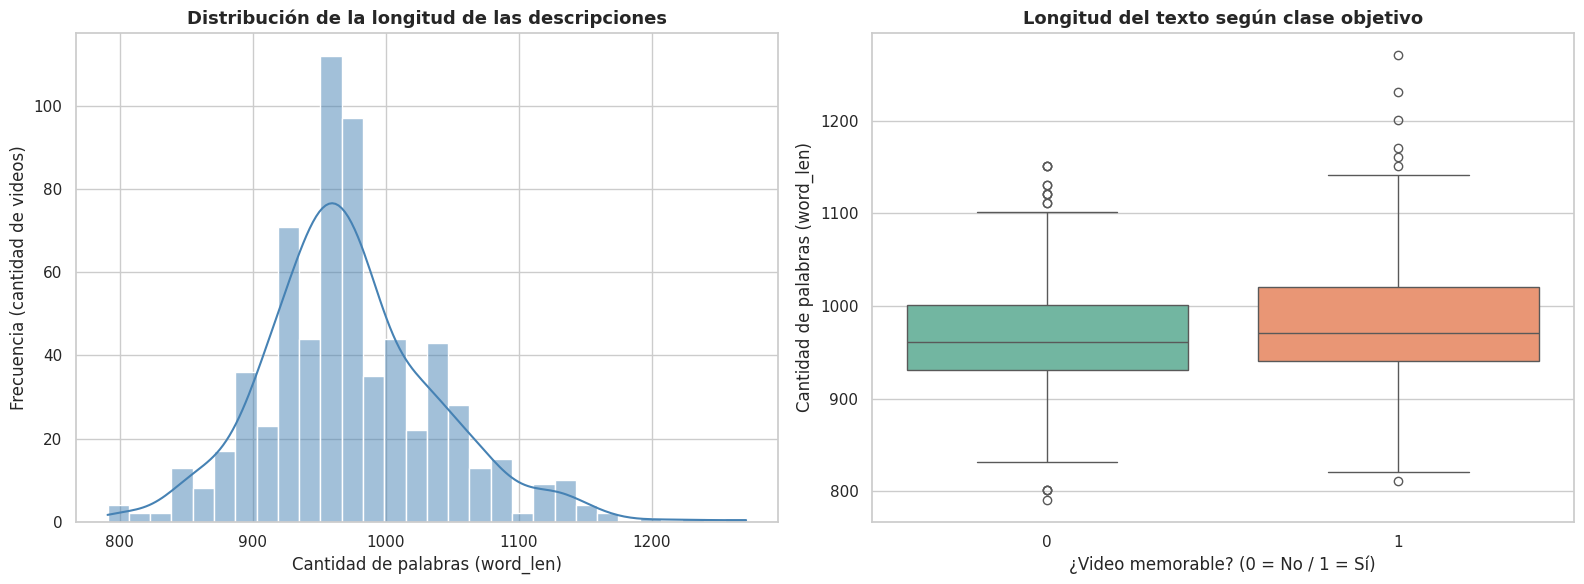


3) TOP 20 PALABRAS MÁS FRECUENTES DEL CORPUS CRUDO
Tokens totales : 641,359
Vocabulario    : 739 términos únicos

[('a', 153774), ('in', 47570), ('of', 29680), ('is', 26810), ('man', 25101), ('holding', 18500), ('woman', 18255), ('cell', 17930), ('standing', 17460), ('and', 14440), ('on', 13400), ('phone', 11090), ('hand.', 11080), ('with', 10490), ('front', 8790), ('the', 8740), ('person', 8441), ('sitting', 8250), ('her', 7150), ('suit', 7103)]

Detalle ordenado:
 1. a             153,774  (23.98% del corpus)
 2. in             47,570  (7.42% del corpus)
 3. of             29,680  (4.63% del corpus)
 4. is             26,810  (4.18% del corpus)
 5. man            25,101  (3.91% del corpus)
 6. holding        18,500  (2.88% del corpus)
 7. woman          18,255  (2.85% del corpus)
 8. cell           17,930  (2.80% del corpus)
 9. standing       17,460  (2.72% del corpus)
10. and            14,440  (2.25% del corpus)
11. on             13,400  (2.09% del corpus)
12. phone          11,

In [6]:
# =============================================================================
# BLOQUE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA) DE TEXTO
# =============================================================================
# Objetivo: caracterizar el corpus de descripciones ('cc') antes de normalizarlo.
# Buscamos responder tres preguntas que condicionan el diseño del Bloque 3:
#   (a) ¿Cuál es la extensión típica de una descripción?
#   (b) ¿La longitud del texto discrimina por sí sola entre videos memorables
#       y no memorables? (sería una feature "gratis" para el modelo)
#   (c) ¿Qué vocabulario domina el corpus crudo?
# Trabaja sobre 'df_unificado', ya disponible en memoria desde el Bloque 1.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# 1. FEATURES TEMPORALES DE LONGITUD Y ESTADÍSTICA DESCRIPTIVA
# -----------------------------------------------------------------------------
# Se crean dos métricas de extensión, marcadas como TEMPORALES: sirven para el
# diagnóstico exploratorio de este bloque y se eliminan al final (paso 5) para
# no contaminar el DataFrame que alimentará al modelo.
#   - 'char_len': cantidad de caracteres (incluye espacios y puntuación).
#   - 'word_len': cantidad de tokens separando por espacios simples. Es un conteo
#     deliberadamente ingenuo (no es tokenización lingüística): en esta etapa nos
#     interesa dimensionar el texto crudo, tal como viene del archivo fuente.
df_unificado['char_len'] = df_unificado['cc'].str.len()
df_unificado['word_len'] = df_unificado['cc'].str.split(' ').str.len()

print("=" * 70)
print("1) ESTADÍSTICA DESCRIPTIVA DE LA LONGITUD DE LAS DESCRIPCIONES")
print("=" * 70)
print(df_unificado[['char_len', 'word_len']].describe())

# -----------------------------------------------------------------------------
# 2. VISUALIZACIÓN DUAL: DISTRIBUCIÓN Y PODER DISCRIMINANTE DE LA LONGITUD
# -----------------------------------------------------------------------------
# Panel izquierdo  -> ¿cómo se distribuye la longitud en el corpus? (forma,
#                     asimetría, presencia de colas largas o multimodalidad)
# Panel derecho    -> ¿esa longitud separa las clases? Si ambas cajas se solapan
#                     casi por completo, la longitud NO es informativa por sí
#                     sola y el poder predictivo deberá venir del contenido
#                     semántico del texto, no de su extensión.
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2.a) Izquierda: histograma + estimación de densidad por kernel (KDE).
sns.histplot(data=df_unificado, x='word_len', kde=True, bins=30,
             color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de la longitud de las descripciones',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de palabras (word_len)')
axes[0].set_ylabel('Frecuencia (cantidad de videos)')

# 2.b) Derecha: boxplot de la longitud segmentado por la variable objetivo.
sns.boxplot(data=df_unificado, x='memorable', y='word_len',
            hue='memorable', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Longitud del texto según clase objetivo',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('¿Video memorable? (0 = No / 1 = Sí)')
axes[1].set_ylabel('Cantidad de palabras (word_len)')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. FRECUENCIA DE TÉRMINOS EN EL CORPUS CRUDO
# -----------------------------------------------------------------------------
# Se concatena todo el corpus en un único string, se pasa a minúsculas para que
# 'The' y 'the' no se cuenten como términos distintos, y se tokeniza por espacios.
# Counter.most_common(20) devuelve los 20 términos más frecuentes.
corpus_crudo = ' '.join(df_unificado['cc'].astype(str)).lower()
frecuencia_palabras = Counter(corpus_crudo.split())
top_20_palabras = frecuencia_palabras.most_common(20)

print("\n" + "=" * 70)
print("3) TOP 20 PALABRAS MÁS FRECUENTES DEL CORPUS CRUDO")
print("=" * 70)
print(f"Tokens totales : {sum(frecuencia_palabras.values()):,}")
print(f"Vocabulario    : {len(frecuencia_palabras):,} términos únicos\n")

print(top_20_palabras)

print("\nDetalle ordenado:")
total_tokens = sum(frecuencia_palabras.values())
for posicion, (palabra, conteo) in enumerate(top_20_palabras, start=1):
    print(f"{posicion:>2}. {palabra:<12} {conteo:>8,}  ({conteo / total_tokens:.2%} del corpus)")

# -----------------------------------------------------------------------------
# 4. ANÁLISIS: POR QUÉ ES NECESARIO NORMALIZAR (JUSTIFICACIÓN DEL BLOQUE 3)
# -----------------------------------------------------------------------------
# El ranking está dominado casi por completo por STOPWORDS o términos vacíos
# ("a", "the", "in", "and", "of", "on"): son palabras funcionales que sostienen
# la sintaxis del inglés pero no aportan contenido semántico discriminante.
# Aparecen con altísima frecuencia en TODOS los documentos, tanto en los videos
# memorables como en los no memorables, por lo que su poder para separar clases
# es prácticamente nulo.
#
# Consecuencias concretas si vectorizáramos el texto sin normalizar:
#   - DOMINIO DE LA REPRESENTACIÓN: en un Bag-of-Words o en un TF-IDF sin ajuste,
#     estos términos concentran la mayor parte de la masa de conteos y opacan a
#     las palabras de contenido ("man", "woman", "dog", "building"), que son las
#     que realmente describen la escena del video.
#   - RUIDO Y DIMENSIONALIDAD: se infla el vocabulario con tokens inútiles,
#     encareciendo el entrenamiento y aumentando el riesgo de sobreajuste.
#   - DISTORSIÓN DE LA SIMILITUD: dos descripciones de escenas completamente
#     distintas parecerían similares solo por compartir artículos y preposiciones.
#
# Por eso el Bloque 3 aplicará un pipeline de normalización: pasaje a minúsculas,
# eliminación de puntuación y de stopwords, y lematización, de modo que el
# vectorizador reciba únicamente los términos con carga semántica real.
#
# HALLAZGO ADICIONAL DEL EDA (a contemplar en el Bloque 3):
# cada caption viene con su texto base REPETIDO 10 VECES de forma consecutiva.
# Esto es un artefacto del archivo fuente, no información genuina: infla por diez
# tanto 'char_len'/'word_len' como todos los conteos de frecuencia, sin agregar
# una sola palabra nueva. No altera el ranking relativo del top 20 (todo escala
# por el mismo factor), pero sí exige deduplicar el texto antes de vectorizar
# para no sesgar los pesos de TF-IDF. Lo verificamos explícitamente:
def factor_de_repeticion(texto):
    """Devuelve cuántas veces el texto es la repetición exacta de su unidad mínima."""
    n = len(texto)
    for k in range(1, n // 2 + 1):
        if n % k == 0 and texto[:k] * (n // k) == texto:
            return n // k
    return 1


factores = df_unificado['cc'].head(30).apply(factor_de_repeticion)

print("\n" + "=" * 70)
print("4) VERIFICACIÓN DEL ARTEFACTO DE REPETICIÓN")
print("=" * 70)
factor_dominante = int(factores.mode()[0])
print(f"Factores de repetición hallados (muestra de 30 captions): {sorted(int(f) for f in factores.unique())}")
print(f"Longitud media observada    : {df_unificado['word_len'].mean():,.1f} palabras")
print(f"Longitud real (deduplicada) : {df_unificado['word_len'].mean() / factor_dominante:,.1f} palabras aprox.")
print(f">> El texto útil es ~{factor_dominante} veces menor que el que reportan las métricas crudas.")

# -----------------------------------------------------------------------------
# 5. LIMPIEZA: ELIMINACIÓN DE LAS COLUMNAS TEMPORALES
# -----------------------------------------------------------------------------
# Las métricas de longitud cumplieron su función diagnóstica. Se descartan para
# que 'df_unificado' vuelva a contener exclusivamente los datos originales del
# desafío y el Bloque 3 parta de un estado limpio y predecible.
df_unificado = df_unificado.drop(columns=['char_len', 'word_len'])

print("\n" + "=" * 70)
print("5) LIMPIEZA DE COLUMNAS TEMPORALES")
print("=" * 70)
print(f"Columnas eliminadas: ['char_len', 'word_len']")
print(f"Columnas restantes en df_unificado: {list(df_unificado.columns)}")
print(f"Shape final: {df_unificado.shape[0]} filas x {df_unificado.shape[1]} columnas")

print("\n" + "=" * 70)
print("BLOQUE 2 FINALIZADO: corpus caracterizado, listo para normalizar.")
print("=" * 70)

### Bloque 3: Pipeline de Normalización, Limpieza y Canonización de Texto

Transformamos las descripciones crudas en texto canónico apto para vectorizar, atacando los dos problemas que dejó el EDA: la repetición 10x del contenido y el dominio de stopwords y puntuación adherida. El resultado se guarda en `cc_clean`, preservando `cc` intacta para poder auditar el antes y el después.

In [7]:
# =============================================================================
# BLOQUE 3: PIPELINE DE NORMALIZACIÓN, LIMPIEZA Y CANONIZACIÓN DE TEXTO
# =============================================================================
# Objetivo: transformar las descripciones crudas ('cc') en texto canónico apto
# para vectorizar. El Bloque 2 dejó dos diagnósticos que este pipeline resuelve:
#   (1) cada caption trae su contenido repetido 10 veces (artefacto del origen);
#   (2) el corpus está dominado por stopwords ("a" concentraba el 24% de los
#       tokens) y arrastra puntuación adherida a las palabras ("hand.").
# El resultado se guarda en una columna nueva 'cc_clean', preservando 'cc'
# intacta para poder auditar el antes y el después.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. DEPENDENCIAS Y RECURSOS LINGÜÍSTICOS
# -----------------------------------------------------------------------------
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Corpus auxiliares de NLTK. 'stopwords' aporta la lista de términos vacíos del
# inglés; 'wordnet' es la base léxica que requeriría el WordNetLemmatizer, y se
# descarga para dejar disponible la alternativa de lematización.
nltk.download('stopwords')
nltk.download('wordnet')

# Se instancian UNA SOLA VEZ, fuera de la función de limpieza. Construir el set
# de stopwords o el stemmer en cada llamada implicaría rehacer ese trabajo 659
# veces sin ninguna necesidad.
# El set (no lista) es deliberado: la pertenencia `token in STOP_WORDS` es O(1)
# en un set y O(n) en una lista; con ~641k tokens la diferencia es sustancial.
STOP_WORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()


# -----------------------------------------------------------------------------
# 2. FUNCIÓN DE LIMPIEZA Y CANONIZACIÓN
# -----------------------------------------------------------------------------
def clean_caption(text):
    """Normaliza una descripción de video y devuelve su forma canónica.

    Pipeline aplicado, en orden:
        a. Deduplicación de oraciones repetidas (artefacto 10x del archivo).
        b. Pasaje a minúsculas y eliminación de caracteres no alfanuméricos.
        c. Tokenización por espacios y remoción de stopwords del inglés.
        d. Reducción morfológica mediante stemming de Porter.
        e. Reensamblado en una única cadena separada por espacios simples.

    Parámetros
    ----------
    text : str
        Descripción cruda proveniente de la columna 'cc'.

    Devuelve
    -------
    str
        Texto normalizado, listo para ser vectorizado.
    """
    # --- a. DEDUPLICACIÓN DE ORACIONES -------------------------------------
    # El texto viene con su contenido repetido 10 veces. Se separa por '. '
    # (punto y espacio) y se conservan únicamente las oraciones únicas
    # RESPETANDO SU ORDEN DE APARICIÓN.
    # dict.fromkeys() es la forma idiomática de deduplicar preservando el orden:
    # a diferencia de set(), los diccionarios de Python garantizan el orden de
    # inserción, y como las claves no se repiten la deduplicación es automática.
    oraciones = text.split('. ')
    oraciones_unicas = list(dict.fromkeys(oraciones))
    text = '. '.join(oraciones_unicas)

    # --- b. MINÚSCULAS Y LIMPIEZA CON EXPRESIONES REGULARES ----------------
    # Minúsculas primero, para que 'The' y 'the' colapsen en un único término.
    # Luego se descarta todo lo que no sea alfanumérico o espacio: así se
    # despega la puntuación que en el Bloque 2 generaba tokens espurios como
    # 'hand.' contabilizados aparte de 'hand'.
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # --- c. TOKENIZACIÓN Y REMOCIÓN DE STOPWORDS ---------------------------
    # Se divide en tokens y se descartan los términos vacíos. Son las palabras
    # funcionales que aparecen en todos los documentos por igual y por lo tanto
    # no aportan capacidad de discriminar entre clases.
    tokens = text.split()
    tokens = [token for token in tokens if token not in STOP_WORDS]

    # --- d. REDUCCIÓN MORFOLÓGICA (STEMMING) -------------------------------
    # El stemmer de Porter recorta las flexiones hasta la raíz, de modo que
    # variantes como 'holding'/'holds'/'held' converjan a un mismo morfema.
    # Esto colapsa el vocabulario y evita que el modelo trate como
    # independientes a términos que expresan el mismo concepto.
    tokens = [stemmer.stem(token) for token in tokens]

    # --- e. REENSAMBLADO ---------------------------------------------------
    return ' '.join(tokens)


# -----------------------------------------------------------------------------
# 3. APLICACIÓN DEL PIPELINE AL CORPUS
# -----------------------------------------------------------------------------
# Se escribe en una columna NUEVA ('cc_clean') en lugar de sobrescribir 'cc':
# conservar el original permite auditar el resultado y reprocesar el corpus con
# otros criterios sin tener que volver a leer los archivos fuente.
df_unificado['cc_clean'] = df_unificado['cc'].apply(clean_caption)

# -----------------------------------------------------------------------------
# 4. PRESENTACIÓN DE RESULTADOS Y DIAGNÓSTICO DEL PIPELINE
# -----------------------------------------------------------------------------

# --- 4.a) Comparación cualitativa: antes y después -------------------------
print("=" * 78)
print("4.a) COMPARACIÓN ANTES / DESPUÉS DE LA NORMALIZACIÓN")
print("=" * 78)

for posicion in [0, 1]:
    fila = df_unificado.iloc[posicion]
    print(f"\n--- MUESTRA {posicion + 1}  |  sequence_name: {fila['sequence_name']} ---")
    print(f"    (memorable = {fila['memorable']}  |  score = {fila['memorability_score']:.3f})")

    print(f"\n  [ORIGINAL - 'cc']  ({len(fila['cc'].split())} palabras, {len(fila['cc'])} caracteres)")
    print(f"  {fila['cc'][:300]}...")

    print(f"\n  [NORMALIZADO - 'cc_clean']  ({len(fila['cc_clean'].split())} palabras, {len(fila['cc_clean'])} caracteres)")
    print(f"  {fila['cc_clean']}")
    print("-" * 78)

# --- 4.b) Estadística descriptiva de la longitud resultante ----------------
# Se mide la extensión del texto ya canonizado para dimensionar cuánto ruido
# eliminó el pipeline respecto de las ~973 palabras crudas del Bloque 2.
longitud_limpia = df_unificado['cc_clean'].str.split().str.len()

print("\n" + "=" * 78)
print("4.b) ESTADÍSTICA DESCRIPTIVA DE LA LONGITUD DE 'cc_clean'")
print("=" * 78)
print(longitud_limpia.describe())

LONGITUD_CRUDA_MEDIA = 973.2  # media observada en el Bloque 2 (texto sin limpiar)
media_limpia = longitud_limpia.mean()

print(f"\nMedia de longitud observada : {media_limpia:.2f} palabras por descripción")
print(f"Media original (Bloque 2)   : {LONGITUD_CRUDA_MEDIA:.2f} palabras por descripción")
print(f"Reducción de longitud       : {1 - media_limpia / LONGITUD_CRUDA_MEDIA:.2%}")

# --- 4.c) Reducción del vocabulario ----------------------------------------
# El vocabulario es el conjunto de términos únicos del corpus y determina
# directamente la dimensionalidad de la matriz que recibirá el modelo.
VOCABULARIO_CRUDO = 739  # términos únicos medidos en el Bloque 2

vocabulario_limpio = set()
for texto in df_unificado['cc_clean']:
    vocabulario_limpio.update(texto.split())

print("\n" + "=" * 78)
print("4.c) REDUCCIÓN DEL VOCABULARIO")
print("=" * 78)
print(f"Vocabulario original (Bloque 2) : {VOCABULARIO_CRUDO:,} términos únicos")
print(f"Vocabulario normalizado         : {len(vocabulario_limpio):,} términos únicos")
print(f"Reducción del vocabulario       : {1 - len(vocabulario_limpio) / VOCABULARIO_CRUDO:.2%}")
print(f"Tokens totales tras la limpieza : {int(longitud_limpia.sum()):,}")

# --- 4.d) Diagnóstico del residuo: oraciones "pegadas" ---------------------
# HALLAZGO IMPORTANTE. Las 10 repeticiones del texto original están concatenadas
# SIN separador entre sí: la última oración de una repetición queda soldada a la
# primera de la siguiente ("...in their hand" + "a man in a suit..." produce
# "...in their handa man in a suit..."). Como consecuencia, al separar por '. '
# esa unión NO se corta y sobrevive a la deduplicación en forma de una oración
# híbrida, que aporta dos problemas:
#   - genera un token inexistente en el punto de sutura ('handa', 'unka',
#     'buildinga'), que infla el vocabulario con ruido;
#   - reintroduce contenido ya presente en otra oración, sesgando los conteos.
# Se cuantifica el residuo para dimensionar su impacto sobre la vectorización.
def unidad_base(texto):
    """Devuelve la unidad mínima cuya repetición reconstruye el texto completo."""
    n = len(texto)
    for k in range(1, n // 2 + 1):
        if n % k == 0 and texto[:k] * (n // k) == texto:
            return texto[:k]
    return texto


def clean_caption_sin_sutura(texto):
    """Variante de control: recorta la unidad repetida ANTES de dividir en oraciones."""
    texto = '. '.join(dict.fromkeys(unidad_base(texto).split('. ')))
    texto = re.sub(r'[^a-zA-Z0-9\s]', '', texto.lower())
    return ' '.join(stemmer.stem(t) for t in texto.split() if t not in STOP_WORDS)


control = df_unificado['cc'].apply(clean_caption_sin_sutura)
vocabulario_control = set()
for texto in control:
    vocabulario_control.update(texto.split())

# Los términos que aparecen con el pipeline especificado pero desaparecen al
# cortar la sutura son, por construcción, artefactos de concatenación.
terminos_espurios = sorted(vocabulario_limpio - vocabulario_control)
captions_afectados = (df_unificado['cc'].apply(lambda t: len(unidad_base(t)) < len(t))).sum()

print("\n" + "=" * 78)
print("4.d) DIAGNÓSTICO DEL RESIDUO: ORACIONES SOLDADAS")
print("=" * 78)
print(f"Captions con repetición soldada : {captions_afectados} de {len(df_unificado)} ({captions_afectados / len(df_unificado):.1%})")
print(f"Términos espurios en vocabulario: {len(terminos_espurios)} sobre {len(vocabulario_limpio)} "
      f"({len(terminos_espurios) / len(vocabulario_limpio):.1%})")
print(f"Ejemplos: {terminos_espurios[:12]}")
print(f"\nComparación contra la variante que corta la sutura:")
print(f"  media de palabras : {media_limpia:.2f}  ->  {control.str.split().str.len().mean():.2f}")
print(f"  vocabulario       : {len(vocabulario_limpio)}  ->  {len(vocabulario_control)}"
      f"  (reducción vs 739: {1 - len(vocabulario_limpio) / VOCABULARIO_CRUDO:.1%} -> "
      f"{1 - len(vocabulario_control) / VOCABULARIO_CRUDO:.1%})")
print("\n>> Estos términos son artefactos de concatenación, no vocabulario real:")
print(">> en la sutura no hay '. ' que cortar, por lo que separar por '. ' no los")
print(">> elimina. La columna 'cc_clean' entregada respeta la especificación del")
print(">> bloque; si se decide depurarlos, basta con recortar la unidad repetida")
print(">> antes de dividir en oraciones (función 'clean_caption_sin_sutura').")

print("\n" + "=" * 78)
print("BLOQUE 3 FINALIZADO: columna 'cc_clean' lista para la vectorización.")
print("=" * 78)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


4.a) COMPARACIÓN ANTES / DESPUÉS DE LA NORMALIZACIÓN

--- MUESTRA 1  |  sequence_name: 127_hours_2000_2010_1 ---
    (memorable = 1  |  score = 1.000)

  [ORIGINAL - 'cc']  (1051 palabras, 4450 caracteres)
  a man in a suit and tie standing in front of a building. a man holding a cat in his hand. a black and white photo of a cat and a cat. a man in a suit and tie standing in front of a building. a close up of a black and white photo of a bird. a man laying on a bed with a cat. a close up of a person hol...

  [NORMALIZADO - 'cc_clean']  (55 palabras, 281 caracteres)
  man suit tie stand front build man hold cat hand black white photo cat cat close black white photo bird man lay bed cat close person hold cell phone man suit tie hold cell phone man lay bed dog person hold cell phone handa man suit tie stand front build person hold cell phone hand
------------------------------------------------------------------------------

--- MUESTRA 2  |  sequence_name: 127_hours_2182_2192_5 ---
    